<a href="https://colab.research.google.com/github/RahulArra/Deep-Learning-Practise/blob/main/dl_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10
# Load the CIFAR-10 dataset

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


#l2 regularization

In [12]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import models, layers, regularizers
from tensorflow.keras.utils import to_categorical

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(-1, 3072)
x_test = x_test.reshape(-1, 3072)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

def build_l2_model():
    model = models.Sequential([
        layers.Dense(200, activation='relu',
                     input_shape=(3072,),
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(168, activation='relu',
                     kernel_regularizer=regularizers.l2(0.001)),
        layers.Dense(10, activation='sigmoid')
    ])
    return model

model_l2 = build_l2_model()

model_l2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train the model
history = model_l2.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2,
    batch_size=32
)

# Evaluate the model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)

print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.2689 - loss: 2.2716 - val_accuracy: 0.3563 - val_loss: 1.8567
Epoch 2/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3740 - loss: 1.8212 - val_accuracy: 0.3842 - val_loss: 1.7995
Epoch 3/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4001 - loss: 1.7557 - val_accuracy: 0.4075 - val_loss: 1.7436
Epoch 4/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4134 - loss: 1.7149 - val_accuracy: 0.3891 - val_loss: 1.7875
Epoch 5/5
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4207 - loss: 1.6860 - val_accuracy: 0.4333 - val_loss: 1.6775
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4447 - loss: 1.6492
Test accuracy: 0.4497


0.4001 for activation layer as relu relu and softmax , less if we use softmax for all3 layers.

Sigmoid causes vanishing gradient for deep networks.
i.e as sigmoid function have a steep curve between 0 and 1 but very flat near 0 and 1 , which results in it's max value of derivative(gradient) is 0.25 , so if multiple layers go on multiplying with less value then it will go near to 0 which result sin layers stop learning and weights update rarely , training slow (0.3641).

0.4005 for relu relu and sigmoid

incresed accuracy by inc in neurons but stil  less



# data augumentation

In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import models, layers, regularizers

# Load the CIFAR-10 dataset again to get original shapes
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
x_train = x_train.astype("float32")
x_test = x_test.astype("float32")

mean = x_train.mean()
std = x_train.std()

x_train = (x_train - mean) / std
x_test = (x_test - mean) / std

# Convert class vectors to binary class matrices
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

#  Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=10,
    zoom_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False,
    vertical_flip=False
)

datagen.fit(x_train)

#  Build Model (with L2 regularization)
def build_l2_model():
    model = models.Sequential([
        layers.Flatten(input_shape=(32, 32, 3)), # Flatten layer handles reshaping for dense layers
        layers.Dense(200, activation='relu'),
        layers.Dense(168, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])
    return model

model_l2 = build_l2_model()

from tensorflow.keras.optimizers import SGD

model_l2.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


#  Train using augmented data
history = model_l2.fit(
    datagen.flow(x_train, y_train, batch_size=32),
    epochs=5,
    validation_data=(x_test, y_test),
    steps_per_epoch=500
)

#  Evaluate model
test_loss, test_acc = model_l2.evaluate(x_test, y_test)
print(f"Test accuracy: {test_acc:.4f}")

Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 12s 21ms/step - accuracy: 0.2871 - loss: 2.0272 - val_accuracy: 0.4073 - val_loss: 1.6825
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.3701 - loss: 1.7677 - val_accuracy: 0.4038 - val_loss: 1.6694
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 21ms/step - accuracy: 0.3881 - loss: 1.7283 - val_accuracy: 0.4241 - val_loss: 1.6356
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.3771 - loss: 1.7175 - val_accuracy: 0.4243 - val_loss: 1.6291
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 11s 22ms/step - accuracy: 0.4043 - loss: 1.6913 - val_accuracy: 0.4363 - val_loss: 1.5941
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.4372 - loss: 1.5882
Test accuracy: 0.4363


In [ ]:
print(history.history['accuracy'])
print(history.history['val_accuracy'])

[0.3084334433078766, 0.374937504529953, 0.4073750078678131, 0.4052579402923584, 0.4206250011920929]
[0.39329999685287476, 0.4097999930381775, 0.4489000141620636, 0.4438999891281128, 0.45989999175071716]


Test accuracy is more using sdg than adam bcoz in adam there is faster convergence , aggreesive updates results in light overfittin , as sgd is slower more stable leads to flatter updates .

increased neurons which should increase overfitting but not in this case bcoz cifar dataset is complet and using mlp on it wil not work properly .

sgd is best in this case and it din't show much diff bcoz of hte dataset


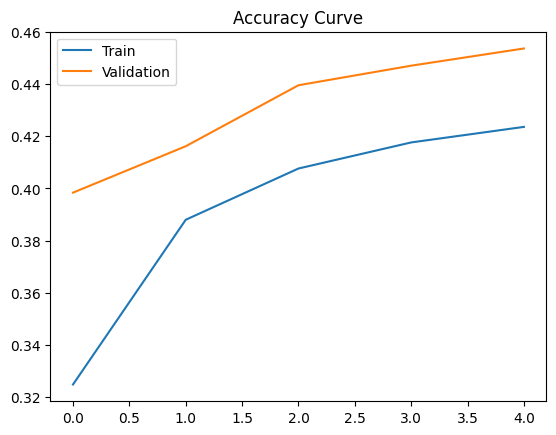

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

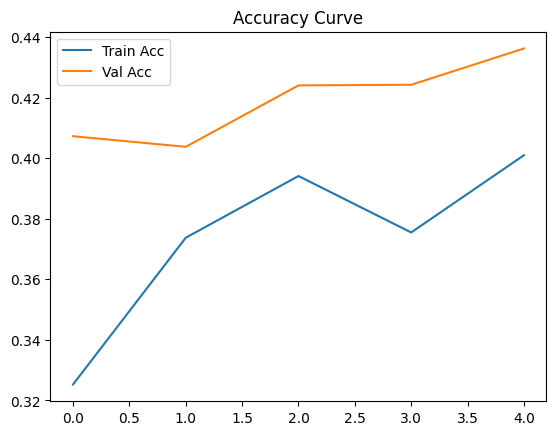

In [19]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

#parameter sharing and tying


In [24]:
#without sharing and tying
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import models, layers
from tensorflow.keras.utils import to_categorical

# Load data
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images → destroys spatial structure
x_train = x_train.reshape(-1, 3072)
x_test = x_test.reshape(-1, 3072)

y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

# MLP Model (NO parameter sharing)
model_mlp = models.Sequential([
    layers.Dense(256, activation='relu', input_shape=(3072,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_mlp.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_mlp.summary()
print("Training MLP...")
history_mlp = model_mlp.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

mlp_test_loss, mlp_test_acc = model_mlp.evaluate(x_test, y_test)
print("MLP Test Accuracy:", mlp_test_acc)

Model: "sequential_15"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_44 (Dense)                │ (None, 256)            │       786,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_45 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_46 (Dense)                │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 820,874 (3.13 MB)

 Trainable params: 820,874 (3.13 MB)

 Non-trainable params: 0 (0.00 B)

Training MLP...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.2470 - loss: 2.0749 - val_accuracy: 0.3699 - val_loss: 1.7712
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3737 - loss: 1.7447 - val_accuracy: 0.4058 - val_loss: 1.6937
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4132 - loss: 1.6527 - val_accuracy: 0.4211 - val_loss: 1.6394
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4328 - loss: 1.5913 - val_accuracy: 0.4272 - val_loss: 1.6121
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4427 - loss: 1.5601 - val_accuracy: 0.4272 - val_loss: 1.6123
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.4534 - loss: 1.5221 - val_accuracy: 0.4560 - val_loss: 1.5591
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.4724 - loss: 1.4803 - val_accuracy: 0.4680 - val_loss: 1.5072
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.4835 - loss: 1.4515 - 

In [26]:
from tensorflow.keras import models, layers

# Reshape x_train and x_test for CNN
x_train = x_train.reshape(-1, 32, 32, 3)
x_test = x_test.reshape(-1, 32, 32, 3)

# CNN Model (WITH parameter sharing)
model_cnn = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D((2,2)),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_cnn.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

model_cnn.summary()
print("Training CNN...")
history_cnn = model_cnn.fit(
    x_train, y_train,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

cnn_test_loss, cnn_test_acc = model_cnn.evaluate(x_test, y_test)
print("CNN Test Accuracy:", cnn_test_acc)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_17"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

Training CNN...
Epoch 1/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - accuracy: 0.3104 - loss: 1.8896 - val_accuracy: 0.4496 - val_loss: 1.5547
Epoch 2/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.5047 - loss: 1.3948 - val_accuracy: 0.5257 - val_loss: 1.3132
Epoch 3/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.5585 - loss: 1.2408 - val_accuracy: 0.5795 - val_loss: 1.2153
Epoch 4/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.5937 - loss: 1.1557 - val_accuracy: 0.6020 - val_loss: 1.1362
Epoch 5/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6206 - loss: 1.0797 - val_accuracy: 0.6275 - val_loss: 1.0843
Epoch 6/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6450 - loss: 1.0267 - val_accuracy: 0.6322 - val_loss: 1.0525
Epoch 7/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6614 - loss: 0.9716 - val_accuracy: 0.6470 - val_loss: 1.0173
Epoch 8/10
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6717 - loss: 0.9353 -

we can clearly see the increase of accuracy from **0.49 to 0.6613**
it's bcoz in mlp we flattened the images which destroyed spatial structure , model does not know which are neighbours are , which are edges and which shapes are , so that it can not learn perfectly .

in cnn we looked at small 3 X 3 regions , detected edges ,  textures , shapes and importantly it Uses the SAME filter everywhere (parameter sharing)